# Task 1: Iris Flower Classification

Classify Iris flowers (setosa, versicolor, virginica) using their measurements with Scikit-learn.

## 1. Load Libraries and Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Iris.csv')
df.head()

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2 KB


The dataset has 150 rows and 6 columns. Each species (setosa, versicolor, virginica) has exactly 50 records — a perfectly balanced dataset.

## 2. Exploratory Data Analysis (EDA)

In [ ]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


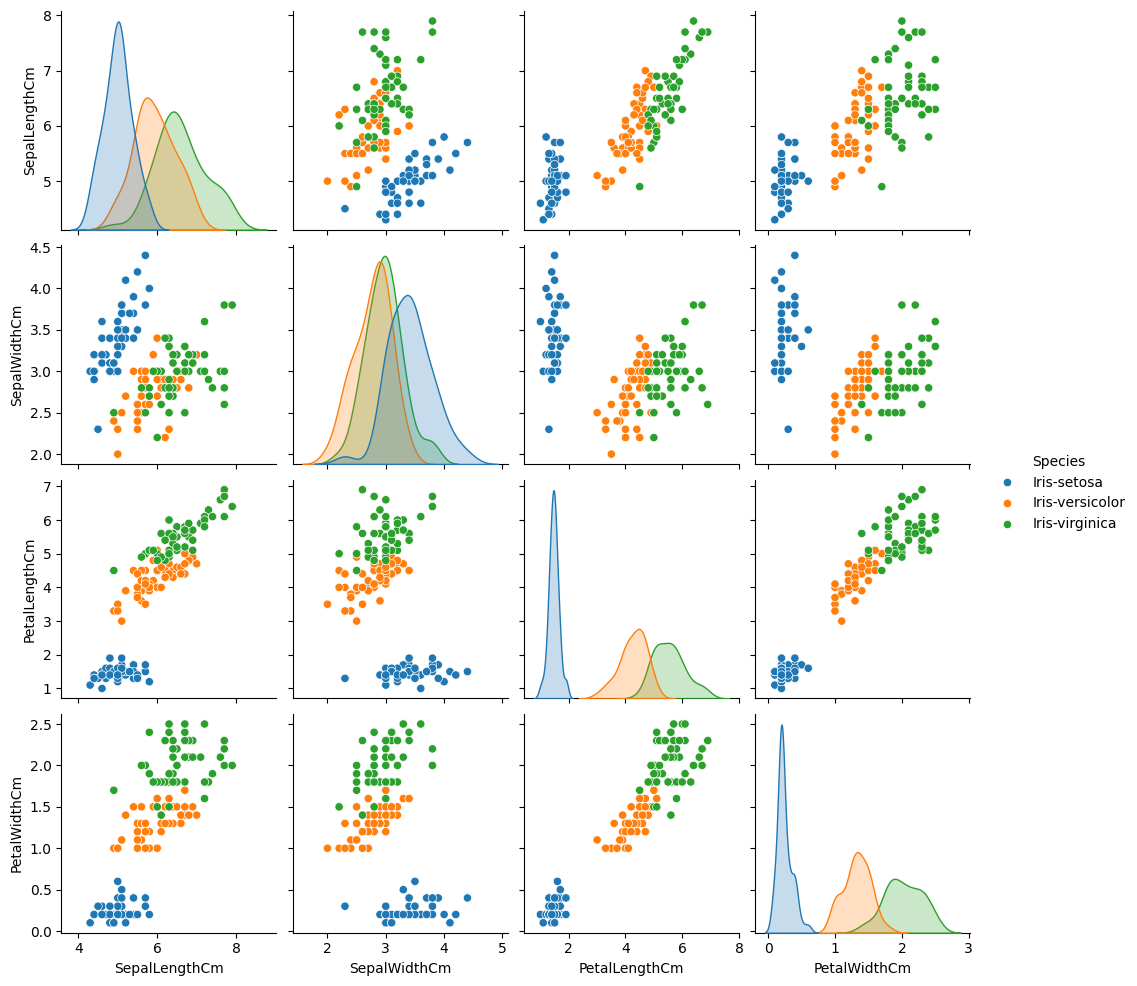

In [ ]:
sns.pairplot(df.drop('Id', axis=1), hue='Species')
plt.show()

**Observation:** `Iris-setosa` is completely separable from the other two species. `versicolor` and `virginica` overlap slightly in petal dimensions.

## 3. Data Preprocessing

In [ ]:
X = df.drop(['Id', 'Species'], axis=1)   # Features
y = df['Species']                         # Target

# Encode species names to numbers (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Classes:", le.classes_)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Train shape: (120, 4) | Test shape: (30, 4)


`stratify=y_encoded` ensures all three species are proportionally represented in both train and test sets.

## 4. Train the Model

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)


**Why Random Forest?** It's a strong general-purpose model for tabular data, not sensitive to feature scaling, and gives feature importance scores out of the box.

## 5. Evaluation

In [ ]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 90.00%

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30


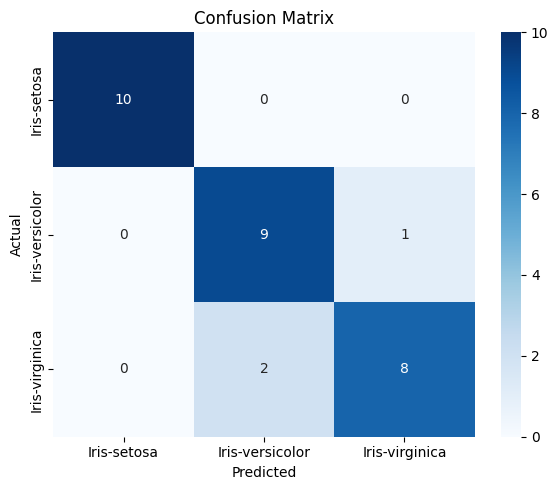

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

The model classifies `setosa` perfectly (100%), with minor confusion between `versicolor` and `virginica` — a known challenge since these two species have overlapping measurements.

## 6. Feature Importance

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

PetalWidthCm     0.437185
PetalLengthCm    0.431466
SepalLengthCm    0.116349
SepalWidthCm     0.015000
dtype: float64


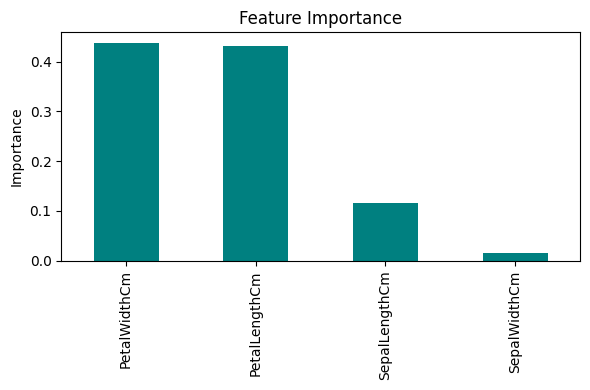

In [ ]:
importances.plot(kind='bar', color='teal', figsize=(6,4))
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Key Classification Concepts

- **Classification**: predicting a category from a known set of classes (here, 3 flower species).
- **Train/Test Split**: training on one part of the data and testing on unseen data to check **generalization**.
- **Accuracy**: percentage of correct predictions out of all predictions.
- **Precision/Recall/F1**: more nuanced metrics than accuracy, important when classes are imbalanced.
- **Confusion Matrix**: shows exactly *where* the model makes mistakes, not just how often.
- **Feature Importance**: helps interpret *which* inputs drive the model's decisions — here, **Petal measurements (86%)** dominate over Sepal measurements (13%).